In [1]:

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from tqdm import tqdm
import time
import random

from extract_links import extract_links

def is_allowed_domain(url, allowed_domains):
    try:
        parsed_url = urlparse(url)
        domain = parsed_url.netloc
        return domain in allowed_domains or any(domain.endswith('.' + d) for d in allowed_domains)
    except:
        return False

def web_crawler(start_url, allowed_domains, max_pages=100, delay=1):
    if isinstance(allowed_domains, str):
        allowed_domains = [allowed_domains]
    allowed_domains = set(allowed_domains)

    start_domain = urlparse(start_url).netloc
    allowed_domains.add(start_domain)

    G = nx.DiGraph()
    queue = [start_url]
    visited_urls = set()

    pbar = tqdm(total=max_pages, desc="Crawling")

    while queue and len(visited_urls) < max_pages:
        current_url = queue.pop(0)

        if current_url in visited_urls:
            continue

        visited_urls.add(current_url)
        pbar.update(1)

        try:
            links_df = extract_links(current_url)

            if links_df is not None and not links_df.empty:
                for link in links_df['url']:
                    if is_allowed_domain(link, allowed_domains):
                        G.add_edge(current_url, link)
                        if link not in visited_urls:
                            queue.append(link)

            if current_url not in G:
                G.add_node(current_url)

            time.sleep(delay + random.uniform(0, 0.5))

        except Exception as e:
            print(f"Error crawling {current_url}: {e}")

    pbar.close()
    return G, visited_urls

def visualize_web_graph(G, output_file=None, label_nodes=False, layout='spring'):
    plt.figure(figsize=(12, 10))

    if layout == 'spring':
        pos = nx.spring_layout(G, seed=42)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'random':
        pos = nx.random_layout(G, seed=42)
    else:
        pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10)

    domains = {}
    colors = []
    unique_domains = set()

    for node in G.nodes():
        domain = urlparse(node).netloc
        domains[node] = domain
        unique_domains.add(domain)

    domain_colors = {domain: i for i, domain in enumerate(unique_domains)}

    for node in G.nodes():
        colors.append(domain_colors[domains[node]])

    nx.draw_networkx_nodes(G, pos, node_size=100, node_color=colors, cmap=plt.cm.tab20)

    if label_nodes:
        labels = {}
        for node in G.nodes():
            parsed = urlparse(node)
            labels[node] = f"{parsed.netloc}{parsed.path[:10]}..."
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    plt.title(f"Web Crawl Graph ({len(G.nodes())} pages, {len(G.edges())} links)")
    plt.axis('off')

    if output_file:
        plt.savefig(output_file, format='png', dpi=300, bbox_inches='tight')

    plt.show()

def analyze_graph(G):
    """Analyze the graph and return some statistics."""
    stats = {
        "Number of nodes": len(G.nodes()),
        "Number of edges": len(G.edges()),
        "Average out-degree": sum(dict(G.out_degree()).values()) / len(G.nodes()) if G.nodes() else 0,
        "Average in-degree": sum(dict(G.in_degree()).values()) / len(G.nodes()) if G.nodes() else 0
    }

    if len(G.nodes()) > 0:
        in_degrees = dict(G.in_degree())
        top_inbound = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        stats["Top pages by incoming links"] = top_inbound

        out_degrees = dict(G.out_degree())
        top_outbound = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        stats["Top pages by outgoing links"] = top_outbound

        try:
            if nx.is_strongly_connected(G):
                stats["Diameter"] = nx.diameter(G)
            else:
                largest_cc = max(nx.strongly_connected_components(G), key=len)
                subgraph = G.subgraph(largest_cc)
                stats["Diameter (largest component)"] = nx.diameter(subgraph)
        except:
            stats["Diameter"] = "Could not compute (graph may not be connected)"

    return stats

def export_to_gephi(G, filename="web_graph.gexf"):
    for node in G.nodes():
        parsed = urlparse(node)
        G.nodes[node]['domain'] = parsed.netloc
        G.nodes[node]['path'] = parsed.path

    nx.write_gexf(G, filename)
    print(f"Graph exported to {filename}")


Crawling:  25%|██▌       | 100/400 [02:37<07:57,  1.59s/it]

Error fetching the URL: HTTPSConnectionPool(host='www.agh.edu.pl', port=443): Max retries exceeded with url: /en/university/history-and-traditions (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x14486a110>, 'Connection to www.agh.edu.pl timed out. (connect timeout=10)'))


Crawling:  30%|███       | 121/400 [03:20<08:01,  1.73s/it]

Error fetching the URL: HTTPSConnectionPool(host='www.agh.edu.pl', port=443): Max retries exceeded with url: /en/stand-with-ukraine (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x1748ea450>, 'Connection to www.agh.edu.pl timed out. (connect timeout=10)'))


Crawling:  39%|███▉      | 156/400 [04:38<09:05,  2.23s/it]

...

Error fetching the URL: 401 Client Error: Unauthorized for url: https://dok.agh.edu.pl/lista.php?id=73


Crawling:  65%|██████▍   | 259/400 [07:47<04:31,  1.92s/it]

Error fetching the URL: 401 Client Error: Unauthorized for url: https://dok.agh.edu.pl/lista.php?id=42


Crawling: 100%|██████████| 400/400 [12:20<00:00,  1.85s/it]



Graph Statistics:
Number of nodes: 9298
Number of edges: 22752
Average out-degree: 2.4469778446977846
Average in-degree: 2.4469778446977846
Top pages by incoming links: [('https://www.agh.edu.pl/', 178), ('https://skos.agh.edu.pl/', 163), ('https://badap.agh.edu.pl/', 150), ('https://oferta-badawcza.agh.edu.pl/', 146), ('https://historia.agh.edu.pl/wiki/Portal_Historia_AGH', 132)]
Top pages by outgoing links: [('https://www.agh.edu.pl/o-agh/dokumenty/uchwaly-senatu-agh', 2139), ('https://dok.agh.edu.pl/lista.php?id=81', 603), ('https://www.agh.edu.pl/pracownicy', 233), ('https://www.agh.edu.pl/o-agh/historia-i-tradycja/doktorzy-honoris-causa', 188), ('https://www.agh.edu.pl/mapa-strony', 163)]
Diameter (largest component): 4


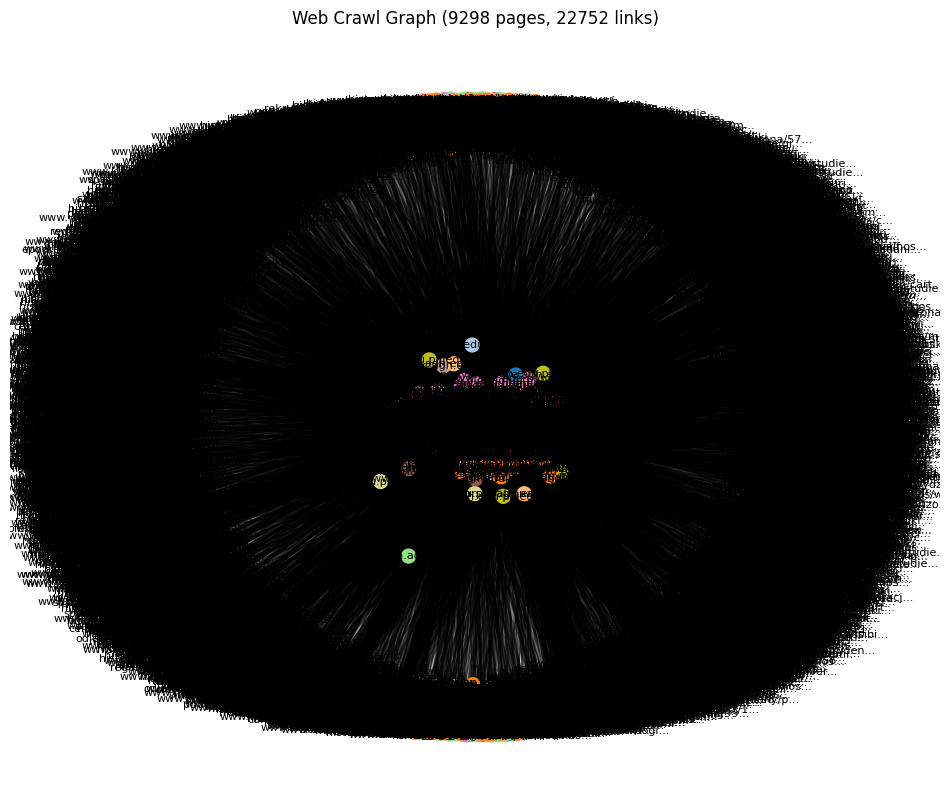

Graph exported to web_graph.gexf


In [7]:
start_url = "https://www.agh.edu.pl"
allowed_domains = ["agh.edu.pl"]

graph, visited = web_crawler(
    start_url=start_url,
    allowed_domains=allowed_domains,
    max_pages=400,
    delay=1
)

stats = analyze_graph(graph)
print("\nGraph Statistics:")
for key, value in stats.items():
    print(f"{key}: {value}")

visualize_web_graph(graph, output_file="web_crawl.png", label_nodes=True)

export_to_gephi(graph)